In [1]:
import itertools
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import torch.distributions as D
import numpy as np
from numpy.random import default_rng
import pymc3 as pm
from scipy.stats import vonmises
from scipy.special import i0

from insilico_stimuli.stimuli import GaborSet, CenterSurround

seed = 42
rng = default_rng(seed=seed)
torch.manual_seed(seed=seed)
EPSILON = 1e-12
mpl.style.use("seaborn")
sns.set_palette("colorblind")
sns.set_context("paper")
sns.set_style("darkgrid")
mpl.style.use("seaborn")

## Utilities

In [2]:
def plot_correlation(trace):
    fig, ax = plt.subplots(dpi=100)
    sns.heatmap(np.corrcoef(trace["neuron"].T), ax=ax, cmap="seismic")
    # make it a square plot
    ax.set_aspect("equal")
    # reduce the tick size
    ax.tick_params(axis='both', which='major', labelsize=9)

In [3]:
def vonmises_pdf(x, mu, kappa):
    return np.exp(kappa * np.cos(x - mu)) / (2 * np.pi * i0(kappa))

In [11]:
def plot_samples(trace, valid_gabors):
    # share x only for 1st row of subplots
    fig, axs = plt.subplots(nrows=2, ncols=5, dpi=150, sharex="row", sharey="row")
    for idx, ax in enumerate(axs[0]):
        response = trace["neuron"][:, idx]
        response_mean = np.mean(trace['neuron'][:, idx].ravel())
        color = "blue" if response_mean < 0.3 else "red"
        sns.histplot(response.ravel(), color=color, stat="probability", element="step", ax=ax)
        ax.text(0.05, 0.95, idx+1, fontsize=6, transform=ax.transAxes)
        ax.text(0.7, 0.95, f"{response_mean:.2f}", fontsize=6, transform=ax.transAxes)
        ax.tick_params(axis='both', which='major', labelsize=5)
        # reduce the font size of the x and y labels
        ax.xaxis.label.set_size(5)
        ax.yaxis.label.set_size(5)
    for idx, ax in enumerate(axs[1]):
        ax.imshow(valid_gabors[idx], cmap="gray", vmin=-1, vmax=1)
        ax.axis("off")
        

## Create Projective Fields of neurons (PFs)

In [6]:
gabor_locations = [(10, 25), (25, 25), (40, 25)]
gabor_params = {
    "canvas_size"         : [50, 50],
    "sizes"               : [15],
    "spatial_frequencies" : [1/20],
    "contrasts"           : [1.0],
    "grey_levels"         : [0.0],
    "eccentricities"      : [0.0],
    "locations"           : gabor_locations,
    "orientations"        : [0., np.pi/2],  
    "phases"              : [np.pi/2, 0.],
    "relative_sf"         : False
}

gabor_set = GaborSet(**gabor_params)

## Remove center gabor with vertical grating

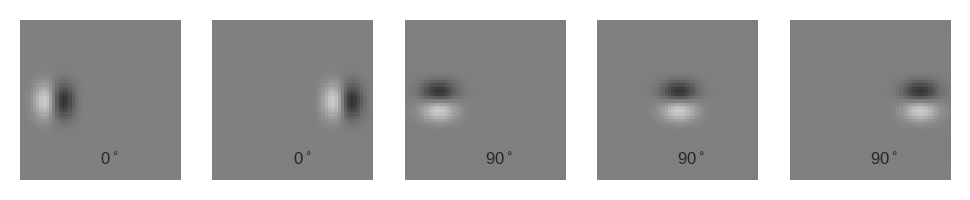

In [7]:
total_param_count = np.prod(gabor_set.num_params())
param_combos = [gabor_set.params_dict_from_idx(idx) for idx in range(total_param_count)]
valid_params_gabors = [(param_combos[idx], gabor_set.stimulus_from_idx(idx)) for idx in range(total_param_count) if not (param_combos[idx]["orientation"] == 0. and param_combos[idx]["location"] == (25, 25))]
valid_params_gabors = sorted(valid_params_gabors, key=lambda x: x[0]["orientation"])
valid_gabors = np.array([gabor for _, gabor in valid_params_gabors])
valid_orientations = np.array([param["orientation"] for param, _ in valid_params_gabors])

fig, axs = plt.subplots(nrows=1, ncols=5, dpi=200)
for idx, ax in enumerate(axs.ravel()):
    gabor = valid_gabors[idx]
    orientation = valid_orientations[idx]
    ax.imshow(gabor, cmap='gray', vmin=-1, vmax=1)
    ax.text(0.5, 0.1, f"{int(np.rad2deg(orientation))}$^\circ$", transform=ax.transAxes, fontsize=6)
    ax.axis("off")


## Create posterior sampling `pymc` model

In [8]:
def sample_posterior(stimulus, vonmises_kappa=5., n_samples=1000):
    vonmises_loc = 0.
    n_neurons = len(valid_gabors)
    stimulus_sigma = torch.abs(torch.rand(1)) + EPSILON
    model = pm.Model()
    with model:
        o = pm.Uniform("orientation", lower=-np.pi/2, upper=np.pi/2)
        z = pm.Exponential(
            "neuron", 
            lam=vonmises_pdf(o - valid_orientations, vonmises_loc, vonmises_kappa),
            shape=n_neurons
        )
        x = pm.Normal("stimulus", mu=torch.tensor(valid_gabors).permute(1, 2, 0) @ z, sigma=stimulus_sigma, observed=stimulus)
        trace = pm.sample(n_samples, return_inferencedata=False)
    return trace

# Present center surround stimulus

## First a center-PF as stimulus

(-0.5, 49.5, 49.5, -0.5)

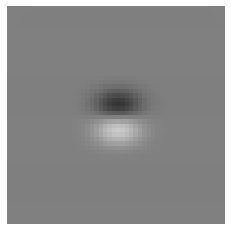

In [9]:
center_PF = valid_gabors[-2]
plt.imshow(center_PF, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

In [10]:
center_trace = sample_posterior(center_PF)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [neuron, orientation]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


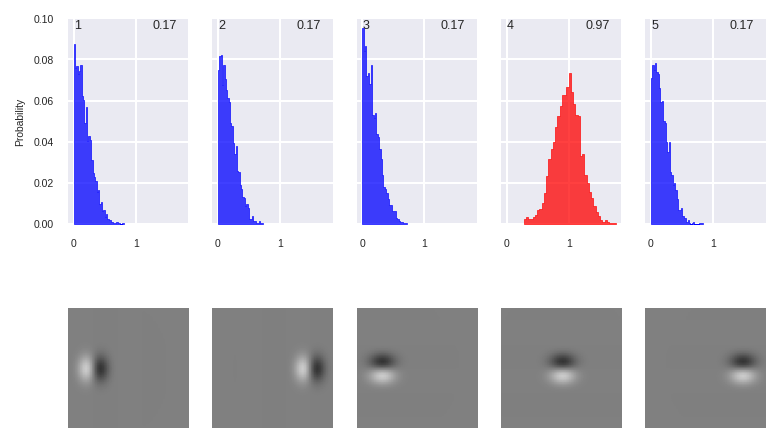

In [12]:
plot_samples(trace, valid_gabors)

## Now a circle-cut center-PF

(-0.5, 49.5, 49.5, -0.5)

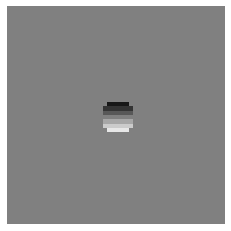

In [14]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": [1/20],
    "spatial_frequencies_surround": [1/10],
    "phases_center": [np.pi/2],
    "phases_surround": [np.pi/2],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi/2],
    "orientations_surround": [np.pi/2],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15/4/50],
    "sizes_surround": [15/4/50],
    "contrasts_center": [1.0],
    "contrasts_surround": [0.],
}

circle_center_PF = CenterSurround(**center_surround_params).images()[0]
plt.imshow(circle_center_PF, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [neuron, orientation]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


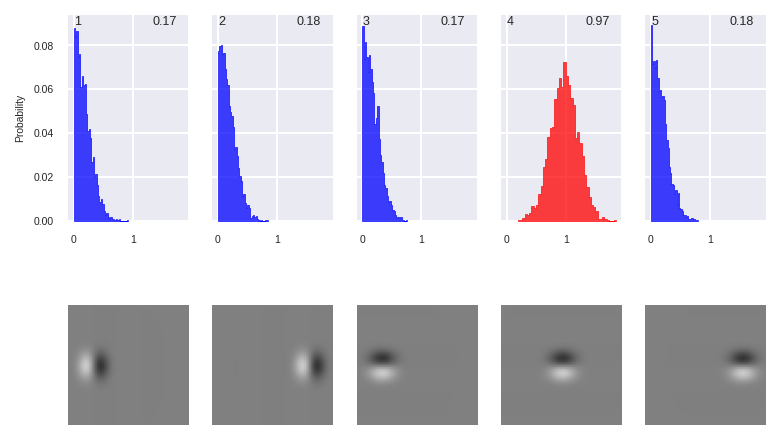

In [15]:
circle_center_trace = sample_posterior(center_PF)
plot_samples(trace, valid_gabors)

## Now present congruent center-surround stimulus

(-0.5, 49.5, 49.5, -0.5)

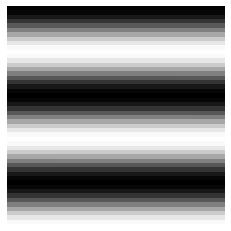

In [17]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": [1/20],
    "spatial_frequencies_surround": [1/20],
    "phases_center": [np.pi/2],
    "phases_surround": [np.pi/2],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi/2],
    "orientations_surround": [np.pi/2],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15/4/50],
    "sizes_surround": [15/4/50],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

congruent = CenterSurround(**center_surround_params).images()[0]
plt.imshow(congruent, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")


In [18]:
congruent_trace = sample_posterior(congruent)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [neuron, orientation]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.
There were 3 divergences after tuning. Increase `target_accept` or reparameterize.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.882403220663434, but should be close to 0.8. Try to increase the number of tuning steps.


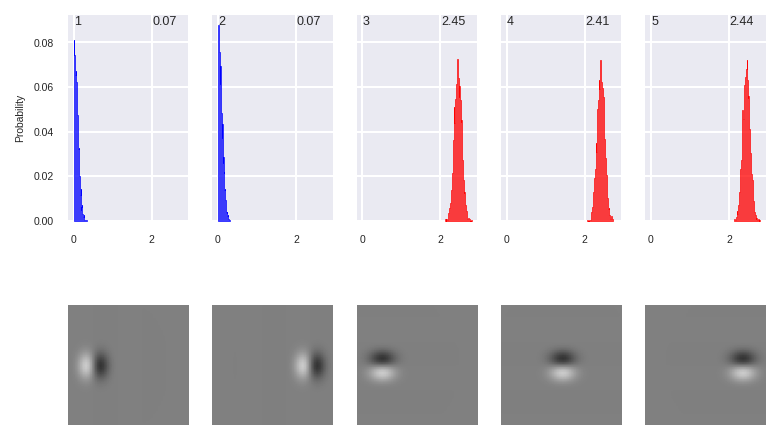

In [20]:
plot_samples(congruent_trace, valid_gabors)

## Now an incongruent center-surround stimulus

(-0.5, 49.5, 49.5, -0.5)

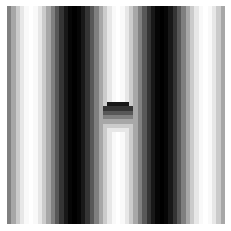

In [22]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1/20],
    "phases_center": gabor_params["phases"],
    "phases_surround": [np.pi/2 + 2*np.pi*1/20*(25-10)],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi/2],
    "orientations_surround": [0.],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15/4/50],
    "sizes_surround": [15/4/50],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

incongruent = CenterSurround(**center_surround_params).images()[0]
plt.imshow(incongruent, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [neuron, orientation]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


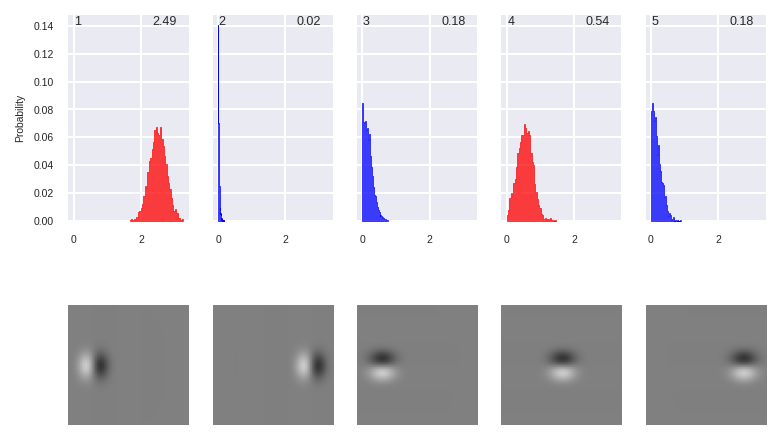

In [23]:
incongruent_trace = sample_posterior(incongruent)
plot_samples(incongruent_trace, valid_gabors)

## Now center-cut incongruent surround stimulus

(-0.5, 49.5, 49.5, -0.5)

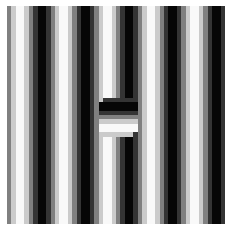

In [20]:
plt.imshow(incongruent_surround, cmap='gray', vmin=-1, vmax=1)
plt.axis('off')

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [neuron, orientation]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


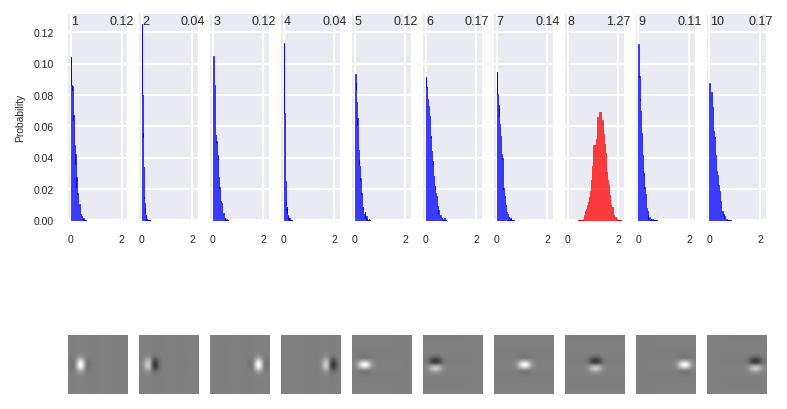

In [21]:
trace_incongruent_surround = sample_posterior(incongruent_surround)
plot_samples(trace_incongruent_surround, valid_gabors)

## Now create the same stimuli but with lower contrast

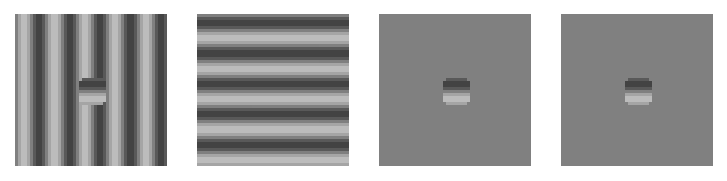

In [30]:
center_surround_params_lowc = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": [1/10],
    "spatial_frequencies_surround": [1/10],
    "phases_center": [np.pi/2],
    "phases_surround": [np.pi/2],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi/2],
    "orientations_surround": [0., np.pi/2],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [5/50],
    "sizes_surround": [5/50],
    "contrasts_center": [0.5, ],
    "contrasts_surround": [0.5, 0],
}

center_surround_lowc = CenterSurround(**center_surround_params_lowc)
center_surround_images_lowc = center_surround_lowc.images()

fig, axs = plt.subplots(nrows=1, ncols=4, dpi=150)
for i, ax in enumerate(axs.ravel()):
    ax.imshow(center_surround_images_lowc[i], cmap='gray', vmin=-1, vmax=1)
    ax.axis('off')


In [31]:
incongruent_surround_lowc, congruent_surround_lowc, circle_cut_center_lowc, _ = center_surround_images_lowc

(-0.5, 49.5, 49.5, -0.5)

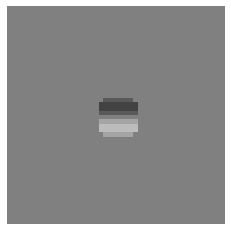

In [32]:
plt.imshow(circle_cut_center_lowc, cmap='gray', vmin=-1, vmax=1)
plt.axis('off')

In [33]:
trace_circle_cut_center_lowc = sample_posterior(circle_cut_center_lowc)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [neuron, orientation]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.
The acceptance probability does not match the target. It is 0.8860702503624366, but should be close to 0.8. Try to increase the number of tuning steps.


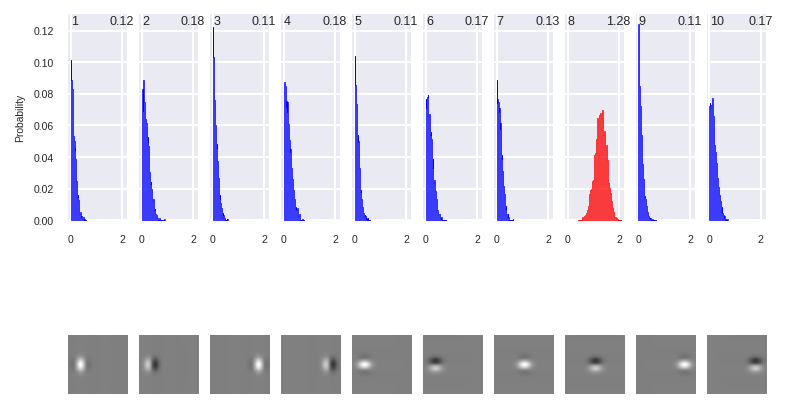

In [34]:
plot_samples(trace_circle_cut_center, valid_gabors)

(-0.5, 49.5, 49.5, -0.5)

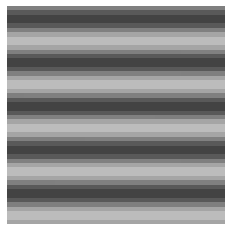

In [35]:
plt.imshow(congruent_surround_lowc, cmap='gray', vmin=-1, vmax=1)
plt.axis('off')

In [36]:
trace_congruent_surround_lowc = sample_posterior(congruent_surround_lowc)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [neuron, orientation]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


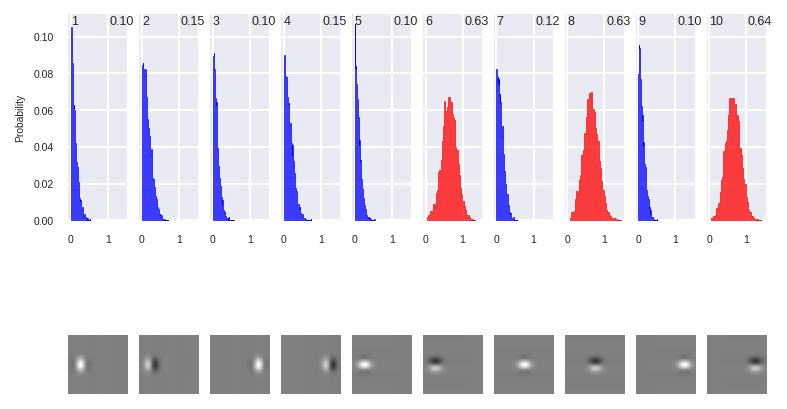

In [37]:
plot_samples(trace_congruent_surround_lowc, valid_gabors)